# Pantheon+SH0ES — Cosmological Parameter Inference
Simplified version of Brout et al. 2022 using `emcee` and statistical errors only.

**Models covered:**
1. Flat ΛCDM — $(H_0, \Omega_m)$
2. Curved ΛCDM — $(H_0, \Omega_m, \Omega_k)$
3. Flat wCDM — $(H_0, \Omega_m, w)$
4. Flat w0waCDM — $(H_0, \Omega_m, w_0, w_a)$

In all models nuisance parameters $(\alpha, \beta)$ are inferred simultaneously. M is fixed to SHOES calibration to avoid H0-M degeneracy.
Corrections $\delta_{\rm bias} = \delta_{\rm host} = 0$ (statistical-only analysis).

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import corner
import os
from astropy.cosmology import FlatLambdaCDM, LambdaCDM, FlatwCDM, Flatw0waCDM
import astropy.units as u

os.makedirs('plots', exist_ok=True)

## 1. Load data and define shared functions

In [17]:
df   = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')
mask = (df['zHD'] > 0.01) & (df['IS_CALIBRATOR'] == 0)
df   = df[mask].reset_index(drop=True)

z      = df['zHD'].values
mB     = df['mB'].values
x1     = df['x1'].values
c      = df['c'].values
mB_err = df['mBERR'].values
x1_err = df['x1ERR'].values
c_err  = df['cERR'].values
print(f'SNe in fit: {len(z)}   z range: {z.min():.4f}–{z.max():.4f}')

# ── Tripp estimator (Eq. 1, Brout+2022) — deltas set to zero ─────────────────
def mu_obs(alpha, beta, M):
    return mB + alpha * x1 - beta * c - M   # delta_bias = delta_host = 0

def sigma_mu(alpha, beta):
    """Statistical uncertainty from error propagation of SALT2 parameters."""
    return np.sqrt(mB_err**2 + (alpha * x1_err)**2 + (beta * c_err)**2)

# ── Generic log-likelihood (same for all cosmological models) ─────────────────
def log_likelihood(mu_th, alpha, beta, M):
    mu_o  = mu_obs(alpha, beta, M)
    sig2  = sigma_mu(alpha, beta)**2
    resid = mu_o - mu_th
    return -0.5 * np.sum(resid**2 / sig2 + np.log(2 * np.pi * sig2))

# ── Shared nuisance prior bounds ──────────────────────────────────────────────
# alpha in (0,1), beta in (1,5), M in (-20.5,-18)
def nuisance_prior_ok(alpha, beta, M):
    return 0.0 < alpha < 1.0 and 1.0 < beta < 5.0 and -20.5 < M < -18.0

# M fixed to SH0ES calibration — breaks H0-M degeneracy
# SNe Ia alone cannot constrain H0 absolutely without an external distance anchor
M_fixed = -19.253

# ── emcee runner (shared by all models) ───────────────────────────────────────
def run_emcee(log_prob, theta0, nwalkers=64, nsteps=4000):  # 4000 suficiente sin degeneración
    ndim = len(theta0)
    
    # Dispersión inicial por parámetro — adaptada a la escala de cada uno
    # H0~70, Om0~0.3, w~-1, Ok~0, alpha~0.15, beta~3.1
    scales = {'H0': 2.0, 'Om0': 0.05, 'Ok': 0.02, 'w0': 0.1, 'wa': 0.2,
              'alpha': 0.01, 'beta': 0.05}
    default_scale = np.abs(theta0) * 0.02 + 0.01
    scatter = default_scale  # fallback si ndim no coincide con un modelo conocido

    # Asigna escalas según número de parámetros del modelo
    scatter_map = {
        4: [2.0, 0.05, 0.01, 0.05],          # flat ΛCDM: H0, Om0, α, β
        5: [2.0, 0.05, 0.02, 0.01, 0.05],    # curved ΛCDM: H0, Om0, Ok, α, β
                                               # flat wCDM:   H0, Om0, w, α, β
        6: [2.0, 0.05, 0.1, 0.2, 0.01, 0.05] # w0waCDM: H0, Om0, w0, wa, α, β
    }
    if ndim in scatter_map:
        scatter = np.array(scatter_map[ndim])

    rng = np.random.default_rng(42)
    pos = np.empty((nwalkers, ndim))
    n = 0
    for _ in range(100_000):
        if n == nwalkers: break
        cand = theta0 + scatter * rng.standard_normal(ndim)
        if np.isfinite(log_prob(cand)):
            pos[n] = cand; n += 1

    moves   = [(emcee.moves.DEMove(), 0.8), (emcee.moves.DESnookerMove(), 0.2)]
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, moves=moves)
    state   = sampler.run_mcmc(pos, 1000, progress=True)  # warm-up reducido
    sampler.reset()
    sampler.run_mcmc(state, nsteps, progress=True)
    return sampler

def get_flat(sampler, burnin_factor=3):
    try:
        tau    = sampler.get_autocorr_time(quiet=True)
        tau    = np.nan_to_num(tau, nan=100.0)
        burnin = int(burnin_factor * tau.max())
        thin   = max(1, int(tau.max() / 2))
    except Exception:
        burnin, thin = 500, 10
    return sampler.get_chain(discard=burnin, thin=thin, flat=True), burnin, thin

def convergence_report(sampler, flat, label):
    chain = sampler.get_chain()
    af    = sampler.acceptance_fraction
    print(f'\n── {label} ──')
    print(f'  Acceptance fraction : mean={af.mean():.3f}  min={af.min():.3f}  max={af.max():.3f}')
    try:
        tau = sampler.get_autocorr_time(quiet=True)
        tau = np.nan_to_num(tau, nan=np.nan)
        print(f'  Autocorr time τ     : {np.round(tau,1)}')
        print(f'  Steps/τ  (>50 ok)   : {np.round(chain.shape[0]/tau,1)}')
        ess = flat.shape[0] / tau
        print(f'  Effective samples   : {np.round(ess).astype(int)}')
    except Exception:
        print('  Autocorr time       : could not compute')
    # Gelman-Rubin R-hat (walkers as chains)
    N, M_w, D = chain.shape
    W    = chain.var(axis=0, ddof=1).mean(axis=0)
    B    = N * chain.mean(axis=0).var(axis=0, ddof=1)
    Rhat = np.sqrt((N-1)/N + B/(N*W))
    print(f'  Gelman-Rubin R-hat  : {np.round(Rhat,4)}  (<1.01 converged)')

def save_corner(flat, labels, title, fname, truths=None):
    fig = corner.corner(flat, labels=labels, truths=truths,
                        quantiles=[0.16, 0.5, 0.84],
                        show_titles=True, title_fmt='.3f',
                        plot_datapoints=False, smooth=1.0)
    fig.suptitle(title, y=1.01, fontsize=13)
    fig.savefig(f'plots/{fname}', dpi=120, bbox_inches='tight')
    plt.show()

def print_results(flat, labels):
    print(f'  {"Param":>10}  {"16%":>9}  {"Median":>9}  {"84%":>9}  {"-σ":>7}  {"+σ":>7}')
    print('  ' + '-'*58)
    for i, lbl in enumerate(labels):
        p16, p50, p84 = np.percentile(flat[:,i], [16, 50, 84])
        print(f'  {lbl:>10}  {p16:>9.4f}  {p50:>9.4f}  {p84:>9.4f}  {p50-p16:>7.4f}  {p84-p50:>7.4f}')

SNe in fit: 1580   z range: 0.0102–2.2614


<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_57441/719234526.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df   = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')


## 2. Model 1 — Flat ΛCDM
Parameters: $(H_0,\, \Omega_m,\, \alpha,\, \beta,\, M)$

In [18]:
def mu_th_flcdm(H0, Om0):
    return 5*np.log10(FlatLambdaCDM(H0=H0, Om0=Om0)
                      .luminosity_distance(z).to(u.Mpc).value) + 25

def log_prob_flcdm(theta):
    H0, Om0, alpha, beta = theta
    if not (50<H0<100 and 0.05<Om0<0.7 and 0<alpha<1 and 1<beta<5):
        return -np.inf
    return log_likelihood(mu_th_flcdm(H0, Om0), alpha, beta, M_fixed)

theta0_flcdm = np.array([70.0, 0.3, 0.15, 3.1])
labels_flcdm = [r'$H_0$', r'$\Omega_m$', r'$\alpha$', r'$\beta$']

print('Running flat ΛCDM...')
sampler_flcdm = run_emcee(log_prob_flcdm, theta0_flcdm)
flat_flcdm, burnin, thin = get_flat(sampler_flcdm)
print(f'Flat samples: {flat_flcdm.shape}  (burnin={burnin}, thin={thin})')

Running flat ΛCDM...


100%|██████████| 4000/4000 [4:20:01<00:00,  3.90s/it]     


Flat samples: (36160, 4)  (burnin=45, thin=7)



── Flat ΛCDM ──
  Acceptance fraction : mean=0.412  min=0.397  max=0.438


  Autocorr time τ     : [15.  15.1 15.1 14.5]
  Steps/τ  (>50 ok)   : [265.8 265.4 264.1 276. ]
  Effective samples   : [2403 2399 2387 2495]
  Gelman-Rubin R-hat  : [1.0016 1.0015 1.0021 1.0016]  (<1.01 converged)
       Param        16%     Median        84%       -σ       +σ
  ----------------------------------------------------------
       $H_0$    71.3206    71.4551    71.5910   0.1345   0.1359
  $\Omega_m$     0.3323     0.3433     0.3543   0.0110   0.0109
    $\alpha$     0.1332     0.1362     0.1391   0.0030   0.0029
     $\beta$     3.0623     3.0933     3.1245   0.0310   0.0312


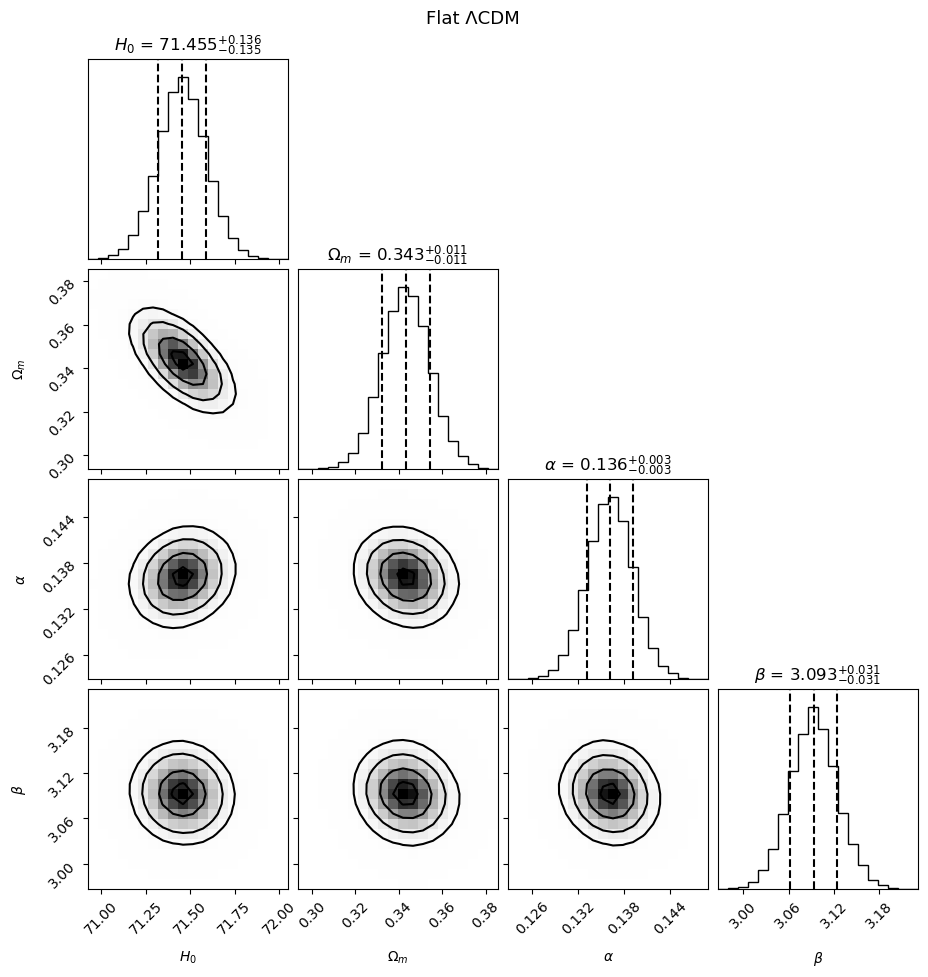

In [19]:
convergence_report(sampler_flcdm, flat_flcdm, 'Flat ΛCDM')
print_results(flat_flcdm, labels_flcdm)
save_corner(flat_flcdm, labels_flcdm, 'Flat ΛCDM', 'corner_flcdm.png')

## 3. Model 2 — Curved ΛCDM
Parameters: $(H_0,\, \Omega_m,\, \Omega_k,\, \alpha,\, \beta,\, M)$

Note: $\Omega_\Lambda = 1 - \Omega_m - \Omega_k$ (astropy handles this internally).

In [20]:
def mu_th_lcdm(H0, Om0, Ok0):
    Ode0 = 1.0 - Om0 - Ok0
    if Ode0 < 0: return np.full(len(z), np.inf)
    cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=Ode0)
    return 5*np.log10(cosmo.luminosity_distance(z).to(u.Mpc).value) + 25

def log_prob_lcdm(theta):
    H0, Om0, Ok0, alpha, beta = theta
    if not (50<H0<100 and 0.05<Om0<0.7 and -0.5<Ok0<0.5 and 0<alpha<1 and 1<beta<5):
        return -np.inf
    mu_th = mu_th_lcdm(H0, Om0, Ok0)
    if not np.all(np.isfinite(mu_th)): return -np.inf
    return log_likelihood(mu_th, alpha, beta, M_fixed)

theta0_lcdm = np.array([70.0, 0.3, 0.0, 0.15, 3.1])
labels_lcdm = [r'$H_0$', r'$\Omega_m$', r'$\Omega_k$', r'$\alpha$', r'$\beta$']

print('Running curved ΛCDM...')
sampler_lcdm = run_emcee(log_prob_lcdm, theta0_lcdm)
flat_lcdm, burnin, thin = get_flat(sampler_lcdm)
print(f'Flat samples: {flat_lcdm.shape}  (burnin={burnin}, thin={thin})')

Running curved ΛCDM...


100%|██████████| 4000/4000 [3:05:16<00:00,  2.78s/it]     


Flat samples: (31552, 5)  (burnin=52, thin=8)



── Curved ΛCDM ──
  Acceptance fraction : mean=0.395  min=0.372  max=0.410
  Autocorr time τ     : [17.2 17.  16.8 17.6 16.8]
  Steps/τ  (>50 ok)   : [233.  235.4 237.5 227.3 238.6]
  Effective samples   : [1838 1857 1874 1793 1882]
  Gelman-Rubin R-hat  : [1.002  1.0018 1.0019 1.0028 1.0022]  (<1.01 converged)
       Param        16%     Median        84%       -σ       +σ
  ----------------------------------------------------------
       $H_0$    71.0844    71.2357    71.3892   0.1512   0.1535
  $\Omega_m$     0.1762     0.2210     0.2674   0.0448   0.0464
  $\Omega_k$     0.1747     0.2788     0.3786   0.1040   0.0998
    $\alpha$     0.1326     0.1354     0.1383   0.0029   0.0028
     $\beta$     3.0569     3.0875     3.1183   0.0306   0.0308


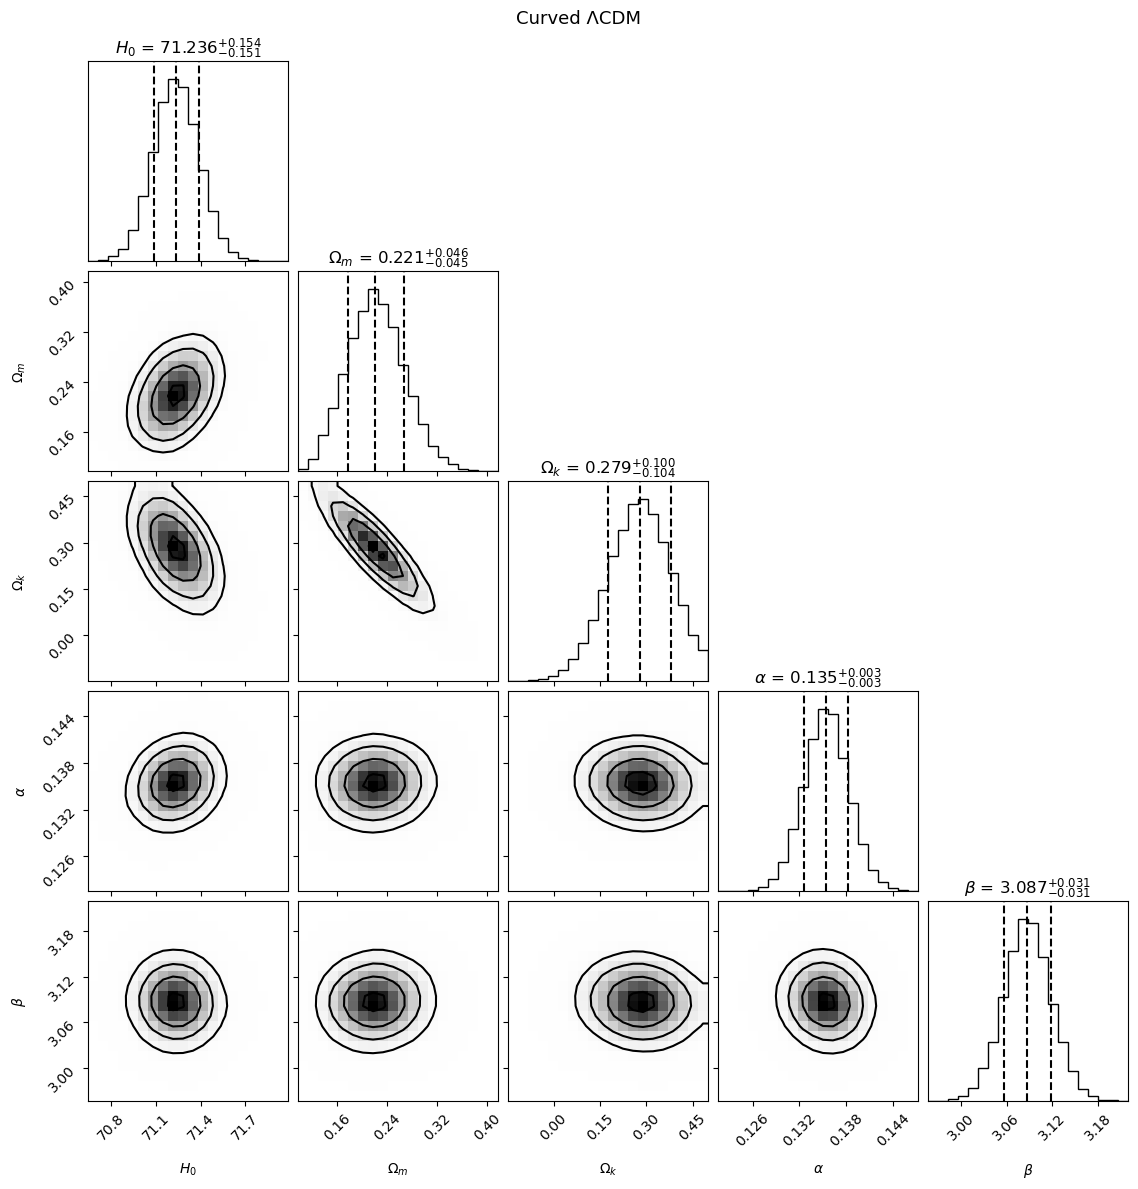

In [21]:
convergence_report(sampler_lcdm, flat_lcdm, 'Curved ΛCDM')
print_results(flat_lcdm, labels_lcdm)
save_corner(flat_lcdm, labels_lcdm, 'Curved ΛCDM', 'corner_lcdm.png')

## 4. Model 3 — Flat wCDM
Parameters: $(H_0,\, \Omega_m,\, w,\, \alpha,\, \beta,\, M)$

Dark energy equation of state: $w = p/\rho = $ const (ΛCDM corresponds to $w=-1$).

In [22]:
def mu_th_wcdm(H0, Om0, w):
    return 5*np.log10(FlatwCDM(H0=H0, Om0=Om0, w0=w)
                      .luminosity_distance(z).to(u.Mpc).value) + 25

def log_prob_wcdm(theta):
    H0, Om0, w, alpha, beta = theta
    if not (50<H0<100 and 0.05<Om0<0.7 and -3.0<w<0.0 and 0<alpha<1 and 1<beta<5):
        return -np.inf
    return log_likelihood(mu_th_wcdm(H0, Om0, w), alpha, beta, M_fixed)

theta0_wcdm = np.array([70.0, 0.3, -1.0, 0.15, 3.1])
labels_wcdm = [r'$H_0$', r'$\Omega_m$', r'$w$', r'$\alpha$', r'$\beta$']

print('Running flat wCDM...')
sampler_wcdm = run_emcee(log_prob_wcdm, theta0_wcdm)
flat_wcdm, burnin, thin = get_flat(sampler_wcdm)
print(f'Flat samples: {flat_wcdm.shape}  (burnin={burnin}, thin={thin})')

Running flat wCDM...


100%|██████████| 4000/4000 [1:24:23<00:00,  1.27s/it]  


Flat samples: (19264, 5)  (burnin=81, thin=13)



── Flat wCDM ──
  Acceptance fraction : mean=0.357  min=0.340  max=0.374
  Autocorr time τ     : [21.8 25.3 27.  20.3 19.7]
  Steps/τ  (>50 ok)   : [183.4 158.  148.  197.3 203.5]
  Effective samples   : [883 761 713 950 980]
  Gelman-Rubin R-hat  : [1.0025 1.0034 1.0035 1.0024 1.0022]  (<1.01 converged)
       Param        16%     Median        84%       -σ       +σ
  ----------------------------------------------------------
       $H_0$    71.0734    71.2196    71.3652   0.1462   0.1456
  $\Omega_m$     0.1197     0.1853     0.2482   0.0656   0.0629
         $w$    -0.8066    -0.7166    -0.6407   0.0899   0.0760
    $\alpha$     0.1325     0.1354     0.1384   0.0029   0.0029
     $\beta$     3.0574     3.0874     3.1179   0.0300   0.0305


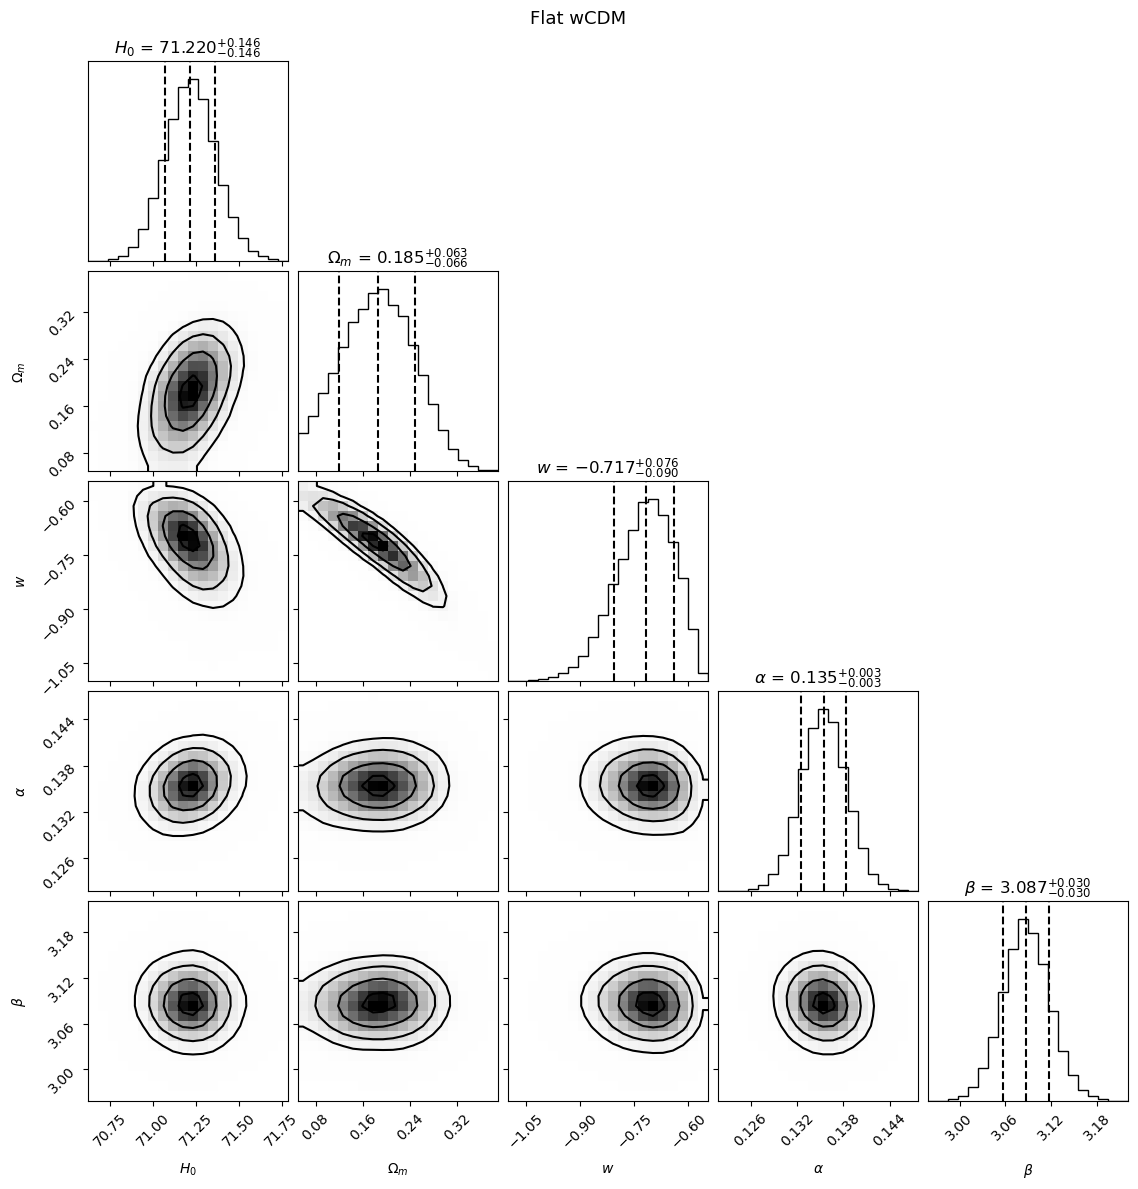

In [23]:
convergence_report(sampler_wcdm, flat_wcdm, 'Flat wCDM')
print_results(flat_wcdm, labels_wcdm)
save_corner(flat_wcdm, labels_wcdm, 'Flat wCDM', 'corner_wcdm.png')

## 5. Model 4 — Flat w0waCDM  *(extra)*
Parameters: $(H_0,\, \Omega_m,\, w_0,\, w_a,\, \alpha,\, \beta,\, M)$

Chevallier-Polarski-Linder parameterization: $w(a) = w_0 + w_a(1-a)$.  
ΛCDM limit: $w_0=-1,\, w_a=0$.

In [24]:
def mu_th_w0wa(H0, Om0, w0, wa):
    return 5*np.log10(Flatw0waCDM(H0=H0, Om0=Om0, w0=w0, wa=wa)
                      .luminosity_distance(z).to(u.Mpc).value) + 25

def log_prob_w0wa(theta):
    H0, Om0, w0, wa, alpha, beta = theta
    if not (50<H0<100 and 0.05<Om0<0.7 and -3<w0<0 and -3<wa<3 and 0<alpha<1 and 1<beta<5):
        return -np.inf
    return log_likelihood(mu_th_w0wa(H0, Om0, w0, wa), alpha, beta, M_fixed)

theta0_w0wa = np.array([70.0, 0.3, -1.0, 0.0, 0.15, 3.1])
labels_w0wa = [r'$H_0$', r'$\Omega_m$', r'$w_0$', r'$w_a$', r'$\alpha$', r'$\beta$']

print('Running flat w0waCDM...')
sampler_w0wa = run_emcee(log_prob_w0wa, theta0_w0wa)
flat_w0wa, burnin, thin = get_flat(sampler_w0wa)
print(f'Flat samples: {flat_w0wa.shape}  (burnin={burnin}, thin={thin})')

Running flat w0waCDM...


100%|██████████| 4000/4000 [1:15:26<00:00,  1.13s/it]


Flat samples: (7552, 6)  (burnin=196, thin=32)



── Flat w0waCDM ──
  Acceptance fraction : mean=0.184  min=0.165  max=0.210
  Autocorr time τ     : [33.3 65.5 46.3 52.  30.3 32.2]
  Steps/τ  (>50 ok)   : [120.1  61.1  86.3  76.9 132.2 124.4]
  Effective samples   : [227 115 163 145 250 235]
  Gelman-Rubin R-hat  : [1.0044 1.0108 1.0066 1.0074 1.0039 1.004 ]  (<1.01 converged)
       Param        16%     Median        84%       -σ       +σ
  ----------------------------------------------------------
       $H_0$    70.9470    71.1293    71.3120   0.1822   0.1828
  $\Omega_m$     0.2120     0.3150     0.3753   0.1030   0.0604
       $w_0$    -0.8569    -0.7667    -0.6857   0.0902   0.0810
       $w_a$    -2.2113    -1.1310    -0.1559   1.0803   0.9751
    $\alpha$     0.1322     0.1352     0.1381   0.0030   0.0030
     $\beta$     3.0564     3.0880     3.1197   0.0316   0.0317


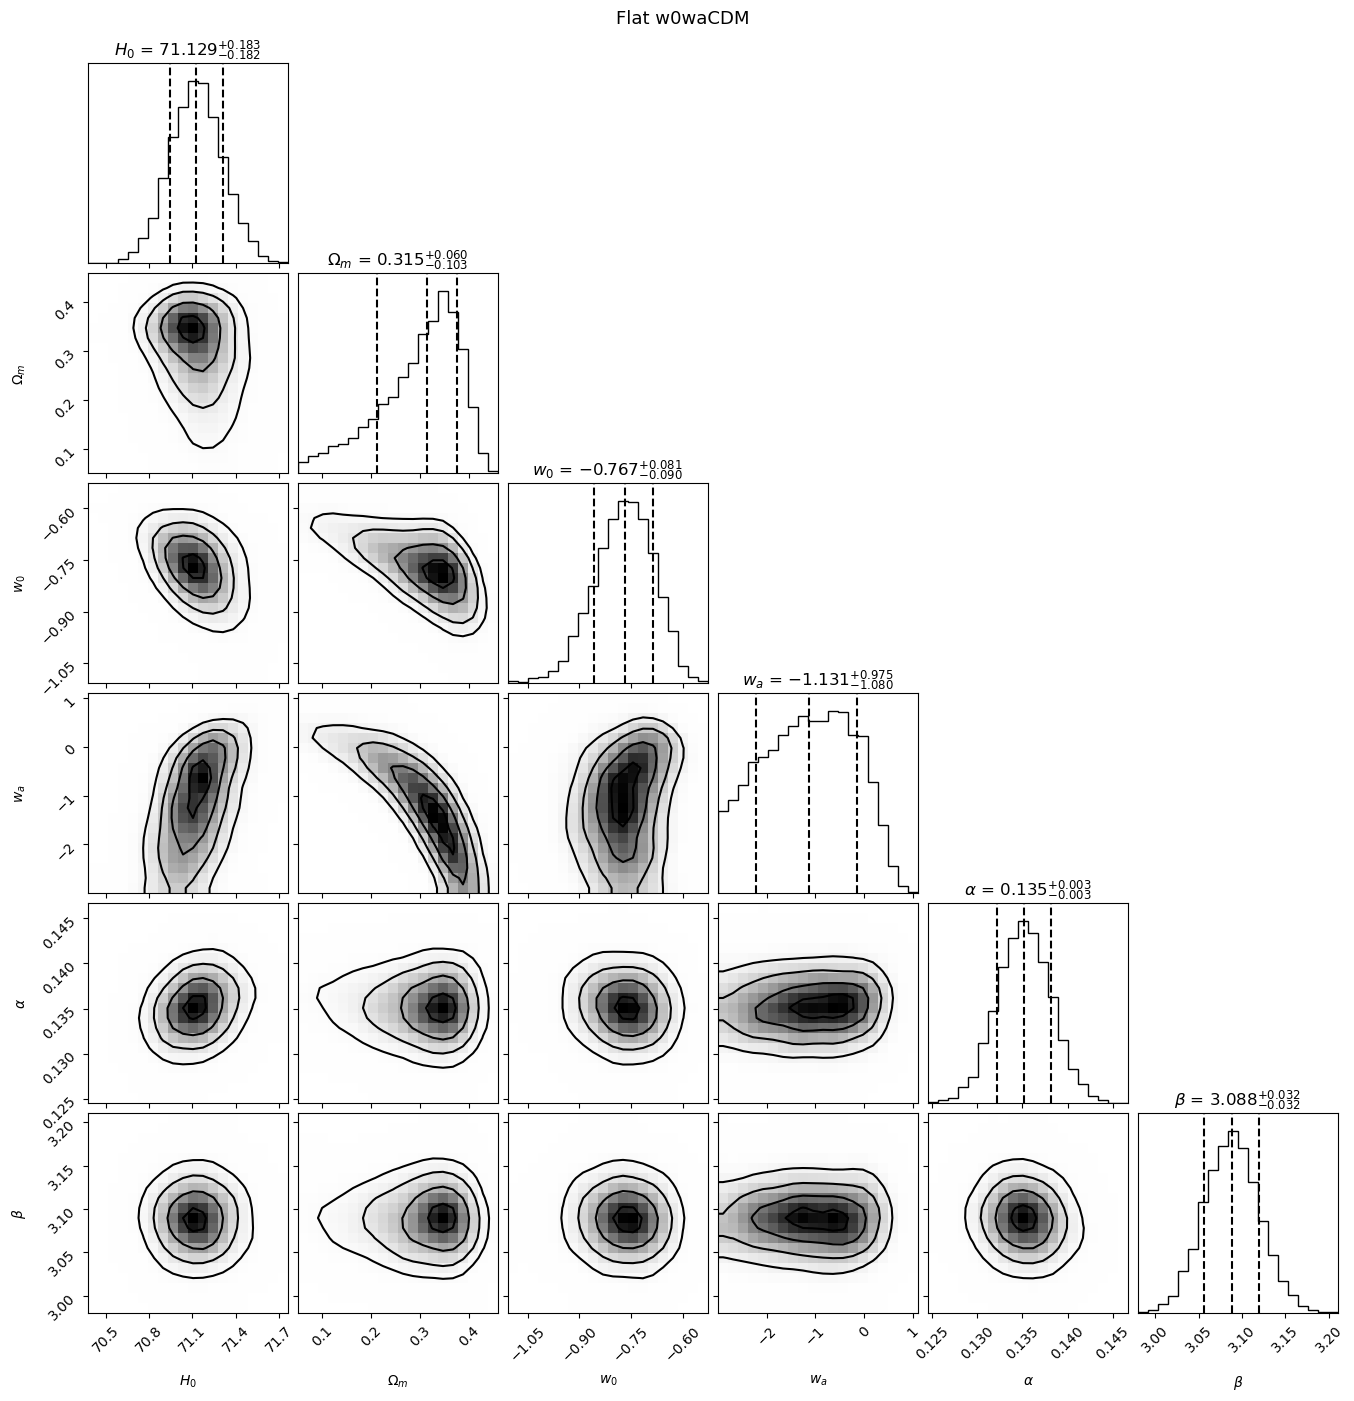

In [25]:
convergence_report(sampler_w0wa, flat_w0wa, 'Flat w0waCDM')
print_results(flat_w0wa, labels_w0wa)
save_corner(flat_w0wa, labels_w0wa, 'Flat w0waCDM', 'corner_w0wa.png')

## 6. Save chains for comparison notebook

In [26]:
os.makedirs('chains', exist_ok=True)
np.save('chains/flat_lcdm.npy',  flat_flcdm)
np.save('chains/curved_lcdm.npy', flat_lcdm)
np.save('chains/flat_wcdm.npy',  flat_wcdm)
np.save('chains/flat_w0wa.npy',  flat_w0wa)
print('Chains saved to chains/')

Chains saved to chains/
